# SynBIC Bioinformatics Seminar: Introduction to PCA, Clustering and Data Analysis, Part 2

___

#### Overview and Motivation

We have previously covered PCA as a linear transform to map data in a way that captures the most variation in a dataset. From the Iris dataset, we could identify a clear separation of the datapoints into (at least) two groups. In an attempt to classify these points into **classes**, a number of different clustering approaches may be employed.


___

#### Summary of this notebook
- Introduction to the need for clustering.
- Supervised vs unsupervised methods.
- K-means, Gaussian Mixture Models, Leiden and HDBSCAN methods of clustering.
- Variability in a method due to randomness.
- The effect of separated vs continuous manifolds.

In [8]:
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

#### sets format of plots to SVG, just a personal preference for better quality plots
%config InlineBackend.figure_format = 'svg'

#### Continuing from last time...
___


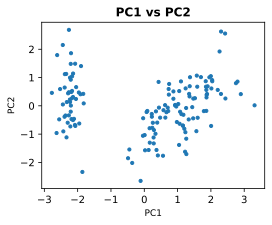

In [10]:
#### Quickly replicate the workflow from notebook 00

iris_df = pd.DataFrame(data=load_iris().data, columns=load_iris().feature_names)

scaled_data = StandardScaler().fit_transform(iris_df)
iris_model = PCA().fit(scaled_data)
iris_pca_df = iris_model.transform(scaled_data)
iris_pca_df = pd.DataFrame(
    iris_pca_df,
    columns=[f"PC{i+1}" for i in range(iris_pca_df.shape[1])]
)

#### Plot PC1 vs PC2 as a scatter plot

plt.figure(figsize=(4, 3))
plt.scatter(
    iris_pca_df['PC1'],
    iris_pca_df['PC2'],
    s=10
)
plt.xlabel('PC1', fontsize=9)
plt.ylabel('PC2', fontsize=9)
plt.title('PC1 vs PC2', fontsize=12, fontweight='bold')
plt.show()


#### The need for clustering
___
As mentioned at the end of the previous notebook, the PCA technique is often used to reveal distributions that are not particularly obvious just by looked at feature relations in the raw data. From the plot above, we can clearly see the datapoints partition themselves into two clear groups, indicating at least two **classes** (classifications) of the data can rationally be inferred. Since this is a toy dataset, one only needs to visit the [Iris Dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html#sklearn.datasets.load_iris) from sklearn to see the true number of classes. In reality, we often do not have this luxury with data measurements. This uncertainty motivates a need for effective clustering techniques in order to best classify nature, though the philosophical debate of whether the human nature of desiring to discretely classify everything it sees is rational is beyond the scope of this workshop ;).

#### Important classes of data clustering methods: supervised and unsupervised techniques
___
It is important to understand that everything that has been covered thus far falls into the domain of machine learning. Clustering methods are no different. At a fundamental level, the difference between supervised and unsupervised methods stems from the involvement of the user in providing constraints to achieve the clustering. There are arguments for and against either approach of which the main one is the tradeoff of reducing human bias for an automated algorithm that is ignorant of biological context and unsertanding.

The clustering methods taught here are summarised below:
- k-means.
- Gaussian Misture Models (GMM).
- Leiden clustering.
- Hierarchical Density-Based Spatial Clustering of Applications with Noise (HDBSCAN).